# Chapter 14 — Bigram Counts as a Table

Chapter 13 stored adjacent-character counts in a dictionary of counters.

This chapter reorganizes the same counts into a rectangular table indexed by token IDs.

By the end of this chapter, you should be able to:

- explain what each row, column, and cell represents;
- build a bigram count table from token IDs;
- verify its shape and total count;
- read rows and columns in the correct direction;
- compute and interpret row and column totals;
- identify nonzero transitions and sparsity;
- visualize counts as a heatmap; and
- explain how table-shaped data prepares us for later matrix operations.

This chapter changes the representation rather than introducing a new model.


## Read the Table Orientation First

A **table** is a rectangular arrangement of values with rows and columns.

In a bigram count table, each row represents a previous token and each column represents a next token.

The cell at `table[previous_token_id][next_token_id]` stores how many times that ordered transition occurred.

For example, the row for `"T"` and column for `"h"` stores the count of `"T" → "h"`.

The direction matters because `"T" → "h"` and `"h" → "T"` are different events.


## Reuse the Prepared Character Fixture

The same small fixture from Chapter 13 lets us compare representations without changing the data.


In [1]:
prepared_text = (
    "The dog ran across the yard.\n"
    "The cat sat near the window.\n"
    "\n"
    "The dog looked at the cat!\n"
    "The cat looked back."
)

print(prepared_text)
print()
print(repr(prepared_text))

The dog ran across the yard.
The cat sat near the window.

The dog looked at the cat!
The cat looked back.

'The dog ran across the yard.\nThe cat sat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'


## Build the Vocabulary and ID Mappings

Token IDs will serve as row and column indexes.

The table is square here because previous and next characters use the same vocabulary.

Other transition tables could be rectangular if their row and column categories differed.


In [2]:
def build_character_mappings(
    text: str,
) -> tuple[list[str], dict[str, int], dict[int, str]]:
    vocabulary = sorted(set(text))
    character_to_id = {
        character: character_id for character_id, character in enumerate(vocabulary)
    }
    id_to_character = {
        character_id: character for character, character_id in character_to_id.items()
    }
    return vocabulary, character_to_id, id_to_character


character_vocabulary, character_to_id, id_to_character = build_character_mappings(
    prepared_text
)
vocabulary_size = len(character_vocabulary)

print("Vocabulary size:", vocabulary_size)
for character_id, character in enumerate(character_vocabulary):
    print(f"{character_id:>3}: {character!r}")

Vocabulary size: 22
  0: '\n'
  1: ' '
  2: '!'
  3: '.'
  4: 'T'
  5: 'a'
  6: 'b'
  7: 'c'
  8: 'd'
  9: 'e'
 10: 'g'
 11: 'h'
 12: 'i'
 13: 'k'
 14: 'l'
 15: 'n'
 16: 'o'
 17: 'r'
 18: 's'
 19: 't'
 20: 'w'
 21: 'y'


## Encode the Fixture

The table-building function will operate on token IDs rather than raw characters.

This same logic could later count character, word, or subword token IDs.


In [3]:
def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    token_ids = []
    for position, character in enumerate(text):
        if character not in character_to_id:
            raise ValueError(f"Unknown character {character!r} at position {position}.")
        token_ids.append(character_to_id[character])
    return token_ids


def decode_character_ids(
    token_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    characters = []
    for position, token_id in enumerate(token_ids):
        if token_id not in id_to_character:
            raise ValueError(f"Unknown token ID {token_id} at position {position}.")
        characters.append(id_to_character[token_id])
    return "".join(characters)


token_ids = encode_characters(prepared_text, character_to_id)
decoded_text = decode_character_ids(token_ids, id_to_character)

assert decoded_text == prepared_text
print("Token count:", len(token_ids))
print("First 80 token IDs:", token_ids[:80])

Token count: 106
First 80 token IDs: [4, 11, 9, 1, 8, 16, 10, 1, 17, 5, 15, 1, 5, 7, 17, 16, 18, 18, 1, 19, 11, 9, 1, 21, 5, 17, 8, 3, 0, 4, 11, 9, 1, 7, 5, 19, 1, 18, 5, 19, 1, 15, 9, 5, 17, 1, 19, 11, 9, 1, 20, 12, 15, 8, 16, 20, 3, 0, 0, 4, 11, 9, 1, 8, 16, 10, 1, 14, 16, 16, 13, 9, 8, 1, 5, 19, 1, 19, 11, 9]


## Inspect Adjacent Token-ID Pairs

Each pair will add one count to exactly one table cell.


In [4]:
print("Position | Previous ID and character | Next ID and character")
print("-" * 59)
for position, (previous_token_id, next_token_id) in enumerate(
    zip(token_ids[:-1], token_ids[1:], strict=True)
):
    if position == 20:
        break
    print(
        f"{position:>8} | {previous_token_id:>3} "
        f"{id_to_character[previous_token_id]!r:>6} | {next_token_id:>3} "
        f"{id_to_character[next_token_id]!r:>6}"
    )

Position | Previous ID and character | Next ID and character
-----------------------------------------------------------
       0 |   4    'T' |  11    'h'
       1 |  11    'h' |   9    'e'
       2 |   9    'e' |   1    ' '
       3 |   1    ' ' |   8    'd'
       4 |   8    'd' |  16    'o'
       5 |  16    'o' |  10    'g'
       6 |  10    'g' |   1    ' '
       7 |   1    ' ' |  17    'r'
       8 |  17    'r' |   5    'a'
       9 |   5    'a' |  15    'n'
      10 |  15    'n' |   1    ' '
      11 |   1    ' ' |   5    'a'
      12 |   5    'a' |   7    'c'
      13 |   7    'c' |  17    'r'
      14 |  17    'r' |  16    'o'
      15 |  16    'o' |  18    's'
      16 |  18    's' |  18    's'
      17 |  18    's' |   1    ' '
      18 |   1    ' ' |  19    't'
      19 |  19    't' |  11    'h'


## Create a Rectangular Zero Table

A **shape** reports the number of rows and columns.

For vocabulary size $V$, this table begins with shape $V \times V$ and every cell equal to zero.


In [5]:
def create_zero_count_table(vocabulary_size: int) -> list[list[int]]:
    if vocabulary_size < 1:
        raise ValueError("vocabulary_size must be at least 1.")
    return [[0 for _ in range(vocabulary_size)] for _ in range(vocabulary_size)]


def table_shape(table: list[list[int]]) -> tuple[int, int]:
    if not table:
        return 0, 0

    column_count = len(table[0])
    if any(len(row) != column_count for row in table):
        raise ValueError("Every table row must have the same length.")
    return len(table), column_count


empty_count_table = create_zero_count_table(vocabulary_size)
row_count, column_count = table_shape(empty_count_table)

print(f"Empty table shape: {row_count} rows × {column_count} columns")
assert (row_count, column_count) == (vocabulary_size, vocabulary_size)

Empty table shape: 22 rows × 22 columns


## Populate the Bigram Count Table

For every adjacent pair, the previous ID chooses a row and the next ID chooses a column.

Explicit ID checks make malformed input fail clearly.


In [6]:
def build_bigram_count_table(
    token_ids: list[int],
    vocabulary_size: int,
) -> list[list[int]]:
    if len(token_ids) < 2:
        raise ValueError("token_ids must contain at least two IDs.")

    count_table = create_zero_count_table(vocabulary_size)
    for position, (previous_token_id, next_token_id) in enumerate(
        zip(token_ids[:-1], token_ids[1:], strict=True)
    ):
        if not 0 <= previous_token_id < vocabulary_size:
            raise ValueError(f"Invalid previous token ID at position {position}.")
        if not 0 <= next_token_id < vocabulary_size:
            raise ValueError(f"Invalid next token ID at position {position + 1}.")
        count_table[previous_token_id][next_token_id] += 1
    return count_table


bigram_count_table = build_bigram_count_table(token_ids, vocabulary_size)
print("Bigram table shape:", table_shape(bigram_count_table))

Bigram table shape: (22, 22)


## Verify the Number of Bigrams

A sequence of $N$ tokens has $N - 1$ adjacent pairs because its final token has no next token.

Summing every table cell checks that each pair was counted exactly once.


In [7]:
def sum_table_values(table: list[list[int]]) -> int:
    return sum(sum(row) for row in table)


total_bigram_count = sum_table_values(bigram_count_table)
expected_bigram_count = len(token_ids) - 1

print("Table total:", total_bigram_count)
print("Expected total:", expected_bigram_count)
assert total_bigram_count == expected_bigram_count

Table total: 105
Expected total: 105


## Read One Cell

The lookup below asks how many times `"h"` followed `"T"`.


In [8]:
previous_character = "T"
next_character = "h"
previous_token_id = character_to_id[previous_character]
next_token_id = character_to_id[next_character]

transition_count = bigram_count_table[previous_token_id][next_token_id]

print("Row:", previous_token_id, repr(previous_character))
print("Column:", next_token_id, repr(next_character))
print("Transition count:", transition_count)

Row: 4 'T'
Column: 11 'h'
Transition count: 4


## Print a Labeled Count Table

Labels make spaces, newlines, and table orientation visible.

Printing the full table is reasonable only because this vocabulary is small.


In [9]:
def print_bigram_count_table(
    table: list[list[int]],
    id_to_character: dict[int, str],
) -> None:
    _, column_count = table_shape(table)
    cell_width = 6
    label_width = 10
    header = " " * label_width + "".join(
        f"{id_to_character[column_id]!r:>{cell_width}}"
        for column_id in range(column_count)
    )
    print("Rows: previous character; columns: next character")
    print(header)
    print("-" * len(header))

    for row_id, row in enumerate(table):
        values = "".join(f"{value:>{cell_width}}" for value in row)
        print(f"{id_to_character[row_id]!r:>{label_width}}{values}")


print_bigram_count_table(bigram_count_table, id_to_character)

Rows: previous character; columns: next character
            '\n'   ' '   '!'   '.'   'T'   'a'   'b'   'c'   'd'   'e'   'g'   'h'   'i'   'k'   'l'   'n'   'o'   'r'   's'   't'   'w'   'y'
----------------------------------------------------------------------------------------------------------------------------------------------
      '\n'     1     0     0     0     3     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0
       ' '     0     0     0     0     0     2     1     3     2     0     0     0     0     0     2     1     0     1     1     3     1     1
       '!'     1     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0
       '.'     2     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0
       'T'     0     0     0     0     0     0     0     0     0     0     0     4     0    

## Read Rows as Possible Next Characters

One row answers which next characters followed one selected previous character.

Rows are the direction used for next-token prediction.


In [10]:
def nonzero_next_character_counts(
    previous_character: str,
    table: list[list[int]],
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
) -> list[tuple[str, int]]:
    if previous_character not in character_to_id:
        raise ValueError(f"Unknown previous character {previous_character!r}.")

    row = table[character_to_id[previous_character]]
    return [
        (id_to_character[next_token_id], count)
        for next_token_id, count in enumerate(row)
        if count > 0
    ]


for previous_character in ["T", "h", "e", " ", "c", ".", "\n"]:
    print("Previous character:", repr(previous_character))
    for next_character, count in nonzero_next_character_counts(
        previous_character,
        bigram_count_table,
        character_to_id,
        id_to_character,
    ):
        print(f"  next {next_character!r:>6}: {count}")
    print()

Previous character: 'T'
  next    'h': 4

Previous character: 'h'
  next    'e': 7

Previous character: 'e'
  next    ' ': 7
  next    'a': 1
  next    'd': 2

Previous character: ' '
  next    'a': 2
  next    'b': 1
  next    'c': 3
  next    'd': 2
  next    'l': 2
  next    'n': 1
  next    'r': 1
  next    's': 1
  next    't': 3
  next    'w': 1
  next    'y': 1

Previous character: 'c'
  next    'a': 3
  next    'k': 1
  next    'r': 1

Previous character: '.'
  next   '\n': 2

Previous character: '\n'
  next   '\n': 1
  next    'T': 3



## Read Columns as Possible Previous Characters

One column answers which previous characters came before one selected next character.

This direction is meaningful for inspection, although generation looks up rows instead.


In [11]:
def nonzero_previous_character_counts(
    next_character: str,
    table: list[list[int]],
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
) -> list[tuple[str, int]]:
    if next_character not in character_to_id:
        raise ValueError(f"Unknown next character {next_character!r}.")

    next_token_id = character_to_id[next_character]
    return [
        (id_to_character[previous_token_id], row[next_token_id])
        for previous_token_id, row in enumerate(table)
        if row[next_token_id] > 0
    ]


print("Next character: 'a'")
for previous_character, count in nonzero_previous_character_counts(
    "a",
    bigram_count_table,
    character_to_id,
    id_to_character,
):
    print(f"  previous {previous_character!r:>6}: {count}")

Next character: 'a'
  previous    ' ': 2
  previous    'b': 1
  previous    'c': 3
  previous    'e': 1
  previous    'r': 1
  previous    's': 1
  previous    'y': 1


## Compute Row and Column Totals

A row total counts occurrences of a character that had a next character.

A column total counts occurrences of a character that had a previous character.

Both sets of totals must sum to the total number of bigrams.


In [12]:
def compute_row_totals(table: list[list[int]]) -> list[int]:
    return [sum(row) for row in table]


def compute_column_totals(table: list[list[int]]) -> list[int]:
    row_count, column_count = table_shape(table)
    if row_count == 0:
        return []
    return [
        sum(table[row_id][column_id] for row_id in range(row_count))
        for column_id in range(column_count)
    ]


row_totals = compute_row_totals(bigram_count_table)
column_totals = compute_column_totals(bigram_count_table)

assert sum(row_totals) == total_bigram_count
assert sum(column_totals) == total_bigram_count

print("Character | Row total | Column total")
print("-" * 38)
for token_id in range(vocabulary_size):
    print(
        f"{id_to_character[token_id]!r:>9} | "
        f"{row_totals[token_id]:>9} | {column_totals[token_id]:>12}"
    )

Character | Row total | Column total
--------------------------------------
     '\n' |         4 |            4
      ' ' |        18 |           18
      '!' |         1 |            1
      '.' |         2 |            3
      'T' |         4 |            3
      'a' |        10 |           10
      'b' |         1 |            1
      'c' |         5 |            5
      'd' |         6 |            6
      'e' |        10 |           10
      'g' |         2 |            2
      'h' |         7 |            7
      'i' |         1 |            1
      'k' |         3 |            3
      'l' |         2 |            2
      'n' |         3 |            3
      'o' |         8 |            8
      'r' |         4 |            4
      's' |         3 |            3
      't' |         8 |            8
      'w' |         2 |            2
      'y' |         1 |            1


## Compare Totals With Character Counts

The final token occurrence has no outgoing bigram, so it is absent from one row total.

The first token occurrence has no incoming bigram, so it is absent from one column total.


In [13]:
def count_token_ids(token_ids: list[int], vocabulary_size: int) -> list[int]:
    counts = [0 for _ in range(vocabulary_size)]
    for token_id in token_ids:
        counts[token_id] += 1
    return counts


character_counts = count_token_ids(token_ids, vocabulary_size)

print("Character | Appearances | Row total | Column total")
print("-" * 55)
for token_id in range(vocabulary_size):
    print(
        f"{id_to_character[token_id]!r:>9} | "
        f"{character_counts[token_id]:>11} | "
        f"{row_totals[token_id]:>9} | {column_totals[token_id]:>12}"
    )

final_token_id = token_ids[-1]
first_token_id = token_ids[0]
assert character_counts[final_token_id] - row_totals[final_token_id] == 1
assert character_counts[first_token_id] - column_totals[first_token_id] == 1

Character | Appearances | Row total | Column total
-------------------------------------------------------
     '\n' |           4 |         4 |            4
      ' ' |          18 |        18 |           18
      '!' |           1 |         1 |            1
      '.' |           3 |         2 |            3
      'T' |           4 |         4 |            3
      'a' |          10 |        10 |           10
      'b' |           1 |         1 |            1
      'c' |           5 |         5 |            5
      'd' |           6 |         6 |            6
      'e' |          10 |        10 |           10
      'g' |           2 |         2 |            2
      'h' |           7 |         7 |            7
      'i' |           1 |         1 |            1
      'k' |           3 |         3 |            3
      'l' |           2 |         2 |            2
      'n' |           3 |         3 |            3
      'o' |           8 |         8 |            8
      'r' |           4 | 

The fixture ends with `"."`, so one period occurrence contributes no outgoing transition.

It starts with `"T"`, so one uppercase `"T"` occurrence contributes no incoming transition.


## Confirm That Direction Changes the Count

Bigram tables are generally not symmetric because reversing a pair changes the event.


In [14]:
transition_pairs = [("T", "h"), ("c", "a"), ("a", "t"), ("d", "o")]

for first_character, second_character in transition_pairs:
    first_id = character_to_id[first_character]
    second_id = character_to_id[second_character]
    forward_count = bigram_count_table[first_id][second_id]
    backward_count = bigram_count_table[second_id][first_id]
    print(
        f"{first_character!r} → {second_character!r}: {forward_count}; "
        f"{second_character!r} → {first_character!r}: {backward_count}"
    )

'T' → 'h': 4; 'h' → 'T': 0
'c' → 'a': 3; 'a' → 'c': 2
'a' → 't': 5; 't' → 'a': 0
'd' → 'o': 3; 'o' → 'd': 0


## List the Nonzero Transitions

The complete table is useful for indexed computation, while a nonzero list is often easier for a person to inspect.


In [15]:
def list_nonzero_bigram_counts(
    table: list[list[int]],
    id_to_character: dict[int, str],
) -> list[tuple[str, str, int]]:
    transitions = []
    for previous_token_id, row in enumerate(table):
        for next_token_id, count in enumerate(row):
            if count > 0:
                transitions.append(
                    (
                        id_to_character[previous_token_id],
                        id_to_character[next_token_id],
                        count,
                    )
                )
    return transitions


nonzero_bigram_counts = list_nonzero_bigram_counts(
    bigram_count_table,
    id_to_character,
)
most_common_transitions = sorted(
    nonzero_bigram_counts,
    key=lambda transition: transition[2],
    reverse=True,
)

print("Nonzero cells:", len(nonzero_bigram_counts))
print("Most common transitions:")
for previous_character, next_character, count in most_common_transitions[:15]:
    print(f"  {previous_character!r:>6} → {next_character!r:>6}: {count}")

Nonzero cells: 57
Most common transitions:
     'e' →    ' ': 7
     'h' →    'e': 7
     'a' →    't': 5
     'T' →    'h': 4
     't' →    ' ': 4
    '\n' →    'T': 3
     ' ' →    'c': 3
     ' ' →    't': 3
     'c' →    'a': 3
     'd' →    'o': 3
     't' →    'h': 3
     ' ' →    'a': 2
     ' ' →    'd': 2
     ' ' →    'l': 2
     '.' →   '\n': 2


## Measure Sparsity

A table is **sparse** when many of its cells are zero.

There are $V^2$ possible character bigrams but only `len(token_ids) - 1` observed bigram positions in this fixture.


In [16]:
possible_cell_count = vocabulary_size * vocabulary_size
nonzero_cell_count = len(nonzero_bigram_counts)
zero_cell_count = possible_cell_count - nonzero_cell_count

print("Possible cells:", possible_cell_count)
print("Nonzero cells:", nonzero_cell_count)
print("Zero cells:", zero_cell_count)
print("Nonzero fraction:", nonzero_cell_count / possible_cell_count)
assert nonzero_cell_count <= total_bigram_count

Possible cells: 484
Nonzero cells: 57
Zero cells: 427
Nonzero fraction: 0.11776859504132231


A zero cell means that the transition was not observed in this fixture.

It does not prove that the transition is impossible in language.


## Visualize the Table as a Heatmap

A heatmap maps larger counts to stronger color intensity and makes the sparse pattern visible at a glance.


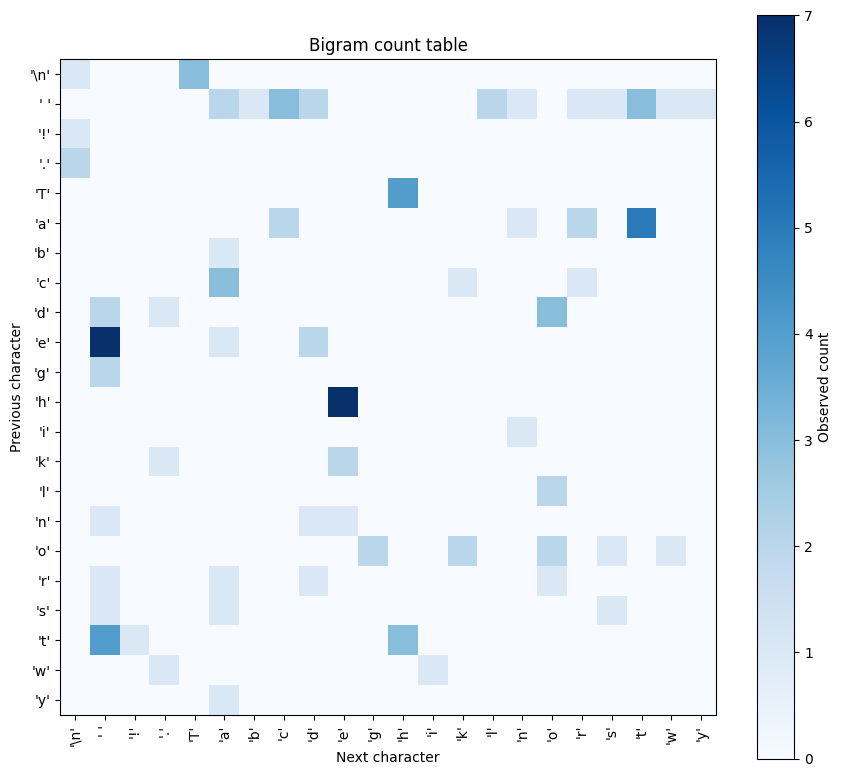

In [17]:
import matplotlib.pyplot as plt  # noqa: I001


tick_positions = list(range(vocabulary_size))
tick_labels = [repr(id_to_character[token_id]) for token_id in tick_positions]

plt.figure(figsize=(9, 8))
plt.imshow(bigram_count_table, aspect="equal", cmap="Blues")
plt.xlabel("Next character")
plt.ylabel("Previous character")
plt.title("Bigram count table")
plt.xticks(tick_positions, tick_labels, rotation=90)
plt.yticks(tick_positions, tick_labels)
plt.colorbar(label="Observed count")
plt.tight_layout()
plt.show()

The heatmap summarizes the same cells as the printed table rather than introducing new data.

Most cells are empty, while a smaller set of observed transitions carries the counts.


## Verify One Count Directly

Counting `"c" → "a"` from the raw text provides an independent check of the indexed table lookup.


In [18]:
def count_transition_directly(
    text: str,
    previous_character: str,
    next_character: str,
) -> int:
    return sum(
        1
        for observed_previous, observed_next in zip(text[:-1], text[1:], strict=True)
        if observed_previous == previous_character and observed_next == next_character
    )


direct_count = count_transition_directly(prepared_text, "c", "a")
table_count = bigram_count_table[character_to_id["c"]][character_to_id["a"]]

print("Direct count:", direct_count)
print("Table count:", table_count)
assert direct_count == table_count

Direct count: 3
Table count: 3


## Verify Equivalence With Chapter 13

Chapter 13's dictionary representation and this table should agree for every possible character pair.


In [19]:
from collections import Counter  # noqa: I001


def count_bigrams_as_dictionary(text: str) -> dict[str, Counter[str]]:
    if len(text) < 2:
        raise ValueError("text must contain at least two characters.")

    counts: dict[str, Counter[str]] = {}
    for previous_character, next_character in zip(text[:-1], text[1:], strict=True):
        if previous_character not in counts:
            counts[previous_character] = Counter()
        counts[previous_character][next_character] += 1
    return counts


dictionary_bigram_counts = count_bigrams_as_dictionary(prepared_text)

for previous_character in character_vocabulary:
    dictionary_row = dictionary_bigram_counts.get(previous_character, Counter())
    for next_character in character_vocabulary:
        table_value = bigram_count_table[character_to_id[previous_character]][
            character_to_id[next_character]
        ]
        assert table_value == dictionary_row[next_character]

print("Dictionary and table counts match for every character pair.")

Dictionary and table counts match for every character pair.


## Compare the Two Representations

The dictionary form stores observed transitions naturally and avoids many explicit zeros.

The table form has a fixed shape, supports direct row and column lookup, and aligns naturally with token IDs.

The table therefore prepares us for matrix-style operations, while the dictionary remains convenient for sparse inspection.


## Treat a Row as a Count Vector

A row is a fixed-length list with one count for every possible next character.

Selecting the row for the current token is the first step in table-based bigram prediction.


In [20]:
previous_character = "c"
previous_token_id = character_to_id[previous_character]
count_row = bigram_count_table[previous_token_id]

print("Previous character:", repr(previous_character))
print("Count row:", count_row)
print("Row length:", len(count_row))
print("Row total:", sum(count_row))
assert len(count_row) == vocabulary_size

print()
print("Nonzero entries:")
for next_token_id, count in enumerate(count_row):
    if count > 0:
        print(f"  {id_to_character[next_token_id]!r:>6}: {count}")

Previous character: 'c'
Count row: [0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0]
Row length: 22
Row total: 5

Nonzero entries:
     'a': 3
     'k': 1
     'r': 1


The next chapter will divide each count in this row by the row total.

That operation will turn the count vector into a conditional probability distribution over next tokens.


## Complete Table Pipeline

The final check rebuilds the table and verifies its central invariants in one place.


In [21]:
final_vocabulary, final_character_to_id, final_id_to_character = (
    build_character_mappings(prepared_text)
)
final_token_ids = encode_characters(prepared_text, final_character_to_id)
final_table = build_bigram_count_table(final_token_ids, len(final_vocabulary))
final_row_totals = compute_row_totals(final_table)
final_column_totals = compute_column_totals(final_table)
final_total = sum_table_values(final_table)

assert table_shape(final_table) == (
    len(final_vocabulary),
    len(final_vocabulary),
)
assert final_total == len(final_token_ids) - 1
assert sum(final_row_totals) == final_total
assert sum(final_column_totals) == final_total

print("Bigram count table summary")
print("-" * 32)
print("Vocabulary size:", len(final_vocabulary))
print("Table shape:", table_shape(final_table))
print("Total bigram count:", final_total)
print(
    "Nonzero transitions:",
    len(list_nonzero_bigram_counts(final_table, final_id_to_character)),
)

Bigram count table summary
--------------------------------
Vocabulary size: 22
Table shape: (22, 22)
Total bigram count: 105
Nonzero transitions: 57


## Common Mistakes

- Keep rows as previous tokens and columns as next tokens.

- Do not assume that reversing a transition preserves its count.

- Remember that a sequence of length $N$ has $N - 1$ adjacent pairs.

- Do not interpret zero as real-world impossibility.

- Distinguish row totals from complete character counts at the final sequence position.

- Distinguish column totals from complete character counts at the first sequence position.

- Print selected rows or summaries instead of an enormous table for a large vocabulary.


## Takeaways

A bigram count table stores previous-token IDs along rows and next-token IDs along columns.

Each cell records one ordered transition count, and all cells together sum to the number of tokens minus one.

Row totals are especially important because next-token prediction begins by selecting the row for the previous token.

The next chapter will normalize each nonempty row into a probability distribution.

That step connects raw transition counts to probabilistic generation.
